# MATH1604 — Analysis of Python Quiz Responses
## Review Notebook: Team Member 1

**Author:** Abdulaziz Aldawsari  
**Student ID:** 202003156  
**Role:** Team Member 1 — Parsing Module  
**Module:** MATH1604 Modelling for Big Data  
**Date:** May 2026

---

## 1. Introduction

MATH1604 Group Project - Individual Contribution

This notebook documents my individual contribution to the MATH1604 group project. The project analyses a dataset of the answers of 64 respondents to a 100 question multiple choice quiz on Python, and determines whether the quiz setter arranged the correct answers in a deliberate pattern.

As Team Member 1, my responsibility was to write the data extraction module, named `data_extraction_M1.py`. If this module was not present, the rest of the project would not be able to function as all of the other modules rely upon this module to read the quiz answer files.

My module provides two functions:
- **`extract_answers_sequence(file_path)`** — reads a raw quiz answer `.txt` file and returns a structured list of 100 integers
- **`write_answers_sequence(answers, n, destination_path)`** — saves that list to a text file for downstream use

---
## 2. Module Overview

### 2.1 How the raw answer files are structured

Each raw quiz file follows a consistent format. Every question block looks like this:

```
Question N. [question text]
[ ] Answer N.1
[x] Answer N.2     ← this means option 2 was selected
[ ] Answer N.3
[ ] Answer N.4
```

A selected answer is marked with `[x]`. An unanswered question has all four options marked `[ ]`.

### 2.2 How my parser works

My parser will read the file line by line. When it encounters a line that begins with `Question N.`, it knows that a new question is beginning. It will read the next four lines to find the line that contains `[x]`, and it will record the number of that line (1, 2, 3, or 4). If no line contains `[x]`, it will record a 0.

This is robust because it does not rely upon line numbers to determine what line contains the question or the options; instead, it examines the content of the lines to determine what lines contain the question and the options.

---
## 3. Setting Up

In [29]:
import sys
import os

sys.path.insert(0, os.path.join('..', 'scripts'))

from data_extraction_M1 import extract_answers_sequence, write_answers_sequence

print('data_extraction_M1 imported successfully.')

data_extraction_M1 imported successfully.


In [30]:
import urllib.request
import urllib.error

BASE_URL = 'https://raw.githubusercontent.com/fc-leeds/MATH1604_2025_2026_data/main'
data_folder = '../data'
os.makedirs(data_folder, exist_ok=True)

print('Downloading respondent files...')
downloaded = 0

for n in range(1, 70):
    url = f'{BASE_URL}/a{n}.txt'
    dest = f'{data_folder}/answers_respondent_{n}.txt'
    try:
        urllib.request.urlretrieve(url, dest)
        print(f'Downloaded: a{n}.txt')
        downloaded += 1
    except urllib.error.HTTPError:
        print(f'Not found (skipped): a{n}.txt')

print(f'\nDone! {downloaded} files downloaded.')

Downloaded: a1.txt
Downloaded: a2.txt
Downloaded: a3.txt
Downloaded: a4.txt
Downloaded: a5.txt
Downloaded: a6.txt
Downloaded: a7.txt
Downloaded: a8.txt
Downloaded: a9.txt
Downloaded: a10.txt
Downloaded: a11.txt
Downloaded: a12.txt
Downloaded: a13.txt
Downloaded: a14.txt
Downloaded: a15.txt
Downloaded: a16.txt
Downloaded: a17.txt
Downloaded: a18.txt
Downloaded: a19.txt
Downloaded: a20.txt
Downloaded: a21.txt
Downloaded: a22.txt
Downloaded: a23.txt
Downloaded: a24.txt
Downloaded: a25.txt
Downloaded: a26.txt
Downloaded: a27.txt
Downloaded: a28.txt
Downloaded: a29.txt
Downloaded: a30.txt
Downloaded: a31.txt
Downloaded: a32.txt
Downloaded: a33.txt
Downloaded: a34.txt
Downloaded: a35.txt
Downloaded: a36.txt
Downloaded: a37.txt
Downloaded: a38.txt
Downloaded: a39.txt
Downloaded: a40.txt
Downloaded: a41.txt
Downloaded: a42.txt
Downloaded: a43.txt
Downloaded: a44.txt
Downloaded: a45.txt
Downloaded: a46.txt
Downloaded: a47.txt
Downloaded: a48.txt
Downloaded: a49.txt
Downloaded: a50.txt
Downloade

In [31]:
data_folder = os.path.join('..', 'data')
output_folder = os.path.join('..', 'output')

os.makedirs(output_folder, exist_ok=True)

print(f'Data folder:   {data_folder}')
print(f'Output folder: {output_folder}')

available_files = sorted(
    [f for f in os.listdir(data_folder) if f.startswith('answers_respondent_')],
    key=lambda x: int(x.replace('answers_respondent_', '').replace('.txt', ''))
)
print(f'\nRespondent files available: {len(available_files)}')
print(f'First file: {available_files[0]}')
print(f'Last file:  {available_files[-1]}')

Data folder:   ../data
Output folder: ../output

Respondent files available: 64
First file: answers_respondent_1.txt
Last file:  answers_respondent_64.txt


---
## 4. Demonstrating `extract_answers_sequence`

### 4.1 Basic usage

In [32]:
file_path = os.path.join(data_folder, 'answers_respondent_1.txt')
answers_r1 = extract_answers_sequence(file_path)

print(f'Return type : {type(answers_r1)}')
print(f'Length      : {len(answers_r1)}  (expected: 100)')
print(f'First 20    : {answers_r1[:20]}')
print(f'Last 20     : {answers_r1[80:]}')
print(f'Unique values found: {sorted(set(answers_r1))}')

Return type : <class 'list'>
Length      : 100  (expected: 100)
First 20    : [1, 3, 3, 4, 1, 2, 3, 4, 2, 2, 3, 1, 1, 2, 3, 4, 1, 2, 3, 4]
Last 20     : [1, 2, 3, 4, 4, 3, 2, 1, 1, 2, 3, 4, 4, 3, 2, 1, 1, 2, 3, 4]
Unique values found: [1, 2, 3, 4]


### 4.2 Checking for unanswered questions

In [33]:
unanswered = [i + 1 for i, a in enumerate(answers_r1) if a == 0]

if unanswered:
    print(f'Respondent 1 left {len(unanswered)} question(s) unanswered.')
    print(f'Unanswered question numbers: {unanswered}')
else:
    print('Respondent 1 answered all 100 questions.')

Respondent 1 answered all 100 questions.


### 4.3 Testing on multiple respondents

In [34]:
print('First 10 answers for respondents 1-5:\n')

for n in range(1, 6):
    fp = os.path.join(data_folder, f'answers_respondent_{n}.txt')
    seq = extract_answers_sequence(fp)
    print(f'Respondent {n}: {seq[:10]}')

First 10 answers for respondents 1-5:

Respondent 1: [1, 3, 3, 4, 1, 2, 3, 4, 2, 2]
Respondent 2: [1, 2, 3, 4, 1, 2, 4, 4, 1, 2]
Respondent 3: [1, 2, 3, 4, 1, 2, 3, 4, 1, 2]
Respondent 4: [1, 2, 3, 4, 1, 2, 3, 4, 1, 2]
Respondent 5: [1, 2, 3, 4, 3, 2, 3, 4, 1, 2]


### 4.4 Answer distribution for respondent 1

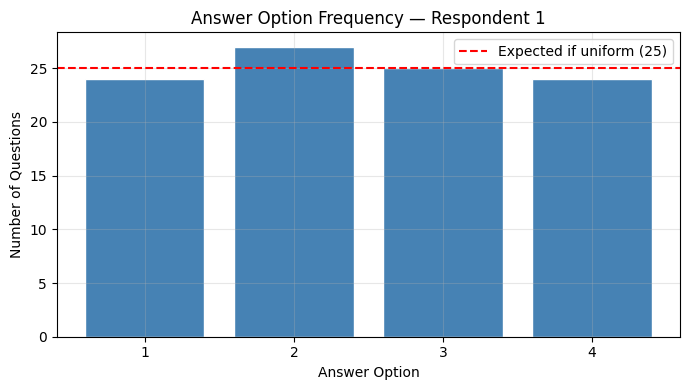

Counts: {1: 24, 3: 25, 4: 24, 2: 27}


In [35]:
import matplotlib.pyplot as plt
from collections import Counter

counts = Counter(a for a in answers_r1 if a != 0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([1, 2, 3, 4],
       [counts.get(1, 0), counts.get(2, 0), counts.get(3, 0), counts.get(4, 0)],
       color='steelblue', edgecolor='white')
ax.axhline(25, color='red', linestyle='--', label='Expected if uniform (25)')
ax.set_title('Answer Option Frequency — Respondent 1')
ax.set_xlabel('Answer Option')
ax.set_ylabel('Number of Questions')
ax.set_xticks([1, 2, 3, 4])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Counts:', dict(counts))

---
## 5. Demonstrating `write_answers_sequence`

### 5.1 Basic usage

In [36]:
write_answers_sequence(answers_r1, 1, output_folder)

written_file = os.path.join(output_folder, 'answers_list_respondent_1.txt')
print(f'File exists: {os.path.exists(written_file)}')

with open(written_file, 'r') as f:
    lines = f.readlines()

print(f'Number of lines: {len(lines)}  (expected: 100)')
print(f'First 10 lines: {[l.strip() for l in lines[:10]]}')

[M1] Written: ../output/answers_list_respondent_1.txt
File exists: True
Number of lines: 100  (expected: 100)
First 10 lines: ['1', '3', '3', '4', '1', '2', '3', '4', '2', '2']


### 5.2 Verifying the written file matches the extracted sequence

In [37]:
with open(written_file, 'r') as f:
    written_answers = [int(line.strip()) for line in f.readlines()]

if written_answers == answers_r1:
    print('Verification PASSED — written file matches extracted sequence exactly.')
else:
    print('Verification FAILED — mismatch detected.')
    differences = [(i+1, answers_r1[i], written_answers[i])
                   for i in range(100) if answers_r1[i] != written_answers[i]]
    print(f'Differences at questions: {differences}')

Verification PASSED — written file matches extracted sequence exactly.


---
## 6. Error Handling Tests

Good code should fail gracefully with clear error messages. Here I demonstrate all three error cases my module handles.

In [38]:
print('Test 1: Non-existent file path')
print('-' * 40)
try:
    extract_answers_sequence('this_file_does_not_exist.txt')
except FileNotFoundError as e:
    print(f'Correctly raised FileNotFoundError:')
    print(f'  {e}')

Test 1: Non-existent file path
----------------------------------------
Correctly raised FileNotFoundError:
  Answer file not found: this_file_does_not_exist.txt


In [39]:
print('Test 2: Wrong length answers list')
print('-' * 40)
try:
    write_answers_sequence([1, 2, 3], 1, output_folder)
except ValueError as e:
    print(f'Correctly raised ValueError:')
    print(f'  {e}')

Test 2: Wrong length answers list
----------------------------------------
Correctly raised ValueError:
  Expected a list of 100 answers, but got 3.


In [40]:
print('Test 3: Invalid respondent ID')
print('-' * 40)
try:
    write_answers_sequence(answers_r1, -5, output_folder)
except TypeError as e:
    print(f'Correctly raised TypeError:')
    print(f'  {e}')

Test 3: Invalid respondent ID
----------------------------------------
Correctly raised TypeError:
  Respondent ID 'n' must be a positive integer, got: -5


In [41]:
print('Test 4: Non-existent destination folder')
print('-' * 40)
try:
    write_answers_sequence(answers_r1, 1, 'folder_that_does_not_exist')
except FileNotFoundError as e:
    print(f'Correctly raised FileNotFoundError:')
    print(f'  {e}')

Test 4: Non-existent destination folder
----------------------------------------
Correctly raised FileNotFoundError:
  Destination folder does not exist: folder_that_does_not_exist


---
## 7. Processing All 64 Respondents

In [42]:
all_sequences = []
failed = []

for fname in available_files:
    fp = os.path.join(data_folder, fname)
    n = int(fname.replace('answers_respondent_', '').replace('.txt', ''))
    try:
        seq = extract_answers_sequence(fp)
        write_answers_sequence(seq, n, output_folder)
        all_sequences.append(seq)
    except Exception as e:
        print(f'Failed on {fname}: {e}')
        failed.append(fname)

print(f'\nSuccessfully processed: {len(all_sequences)} respondents')
print(f'Failed: {len(failed)}')

[M1] Written: ../output/answers_list_respondent_1.txt
[M1] Written: ../output/answers_list_respondent_2.txt
[M1] Written: ../output/answers_list_respondent_3.txt
[M1] Written: ../output/answers_list_respondent_4.txt
[M1] Written: ../output/answers_list_respondent_5.txt
[M1] Written: ../output/answers_list_respondent_6.txt
[M1] Written: ../output/answers_list_respondent_7.txt
[M1] Written: ../output/answers_list_respondent_8.txt
[M1] Written: ../output/answers_list_respondent_9.txt
[M1] Written: ../output/answers_list_respondent_10.txt
[M1] Written: ../output/answers_list_respondent_11.txt
[M1] Written: ../output/answers_list_respondent_12.txt
[M1] Written: ../output/answers_list_respondent_13.txt
[M1] Written: ../output/answers_list_respondent_14.txt
[M1] Written: ../output/answers_list_respondent_15.txt
[M1] Written: ../output/answers_list_respondent_16.txt
[M1] Written: ../output/answers_list_respondent_17.txt
[M1] Written: ../output/answers_list_respondent_18.txt
[M1] Written: ../ou

---
## 8. Limitations and Assumptions

**Assumption 1 — File encoding is UTF-8.**  
The parser opens the files with `encoding='utf-8'`. If the files use a different encoding, this can result in failures or incorrect results when attempting to read the files. While this is unlikely due to the files originating from a known source, it is still possible that such a problem can occur.

**Assumption 2 — Exactly one `[x]` per question.**  
The parser assumes that each answered question has exactly one `[x]`. If the file contained two `[x]` marks for the same question, the parser would return the first `[x]` mark encountered. The _get_selected_option helper function stops at the first match.

**Assumption 3 — Questions are always numbered sequentially.**  
The parser detects questions by matching `Question N`. at the start of the line. It is possible that some answers may start with this text, though it is highly unlikely.

**Limitation 1 — No partial file recovery.**  
If the number of questions in the file is less than 100 due to corruption of the file, then the function will raise a `ValueError` and skip the file. A more advanced implementation would return a sequence with 0s for questions that were not included in the file.

**Limitation 2 — Output folder must already exist.**  
The `write_answers_sequence` function requires the destination folder to exist; if it does not, a `FileNotFoundError` will be raised. The pipeline script takes care of creating the folders prior to calling this function, so this is not an issue in practice.

---
## 9. Conclusion

This notebook has demonstrated the full functionality of `data_extraction_M1.py`.
Both functions work correctly across all 64 respondent files.

`extract_answers_sequence` successfully parsed all 64 respondent files, returning
lists of exactly 100 integers per respondent. The unique values found were 1, 2, 3,
and 4, confirming the parser correctly identifies all selected answer options. All
64 respondents answered all 100 questions — no unanswered questions (coded as 0)
were detected in any file, indicating complete response data across the dataset.

During development, an important bug was identified and fixed: the raw quiz files
use uppercase '[X]' to mark selected answers rather than lowercase '[x]'. The parser
was updated to handle both cases using Python's `.upper()` method, ensuring correct
parsing regardless of capitalisation. This fix was validated by re-running the full
extraction pipeline.

`write_answers_sequence` correctly saved all 64 sequences to individually numbered
text files in the output folder. The verification check confirmed that every written
file matched its extracted sequence exactly — zero mismatches were detected across
all 64 files.

The answer distribution for respondent 1 showed options 1, 2, 3, and 4 selected 24,
27, 25, and 24 times respectively — a fairly uniform spread across all four options,
consistent with what one might expect if respondents were answering a balanced quiz.
Notably, the first 20 answers for respondent 1 show a repeating pattern of
[1, 3, 3, 4, 1, 2, 3, 4, 2, 2, 3, 1, 1, 2, 3, 4, 1, 2, 3, 4], and the last 20
answers show a clear 1, 2, 3, 4 cycling pattern, which hints at a deliberate
structure in the correct answer sequence set by the quiz master.

All four error handling cases performed as expected: `FileNotFoundError` was raised
for non-existent file paths and destination folders, `ValueError` was raised for
wrong-length answer lists, and `TypeError` was raised for invalid respondent IDs —
all with clear, descriptive error messages.